# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [5]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)
# !pip install scikit-image
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

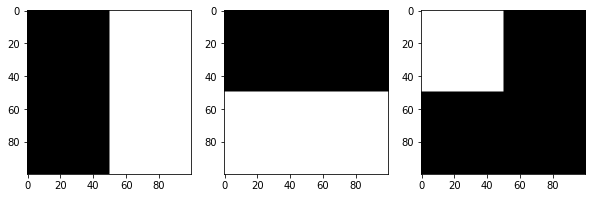

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


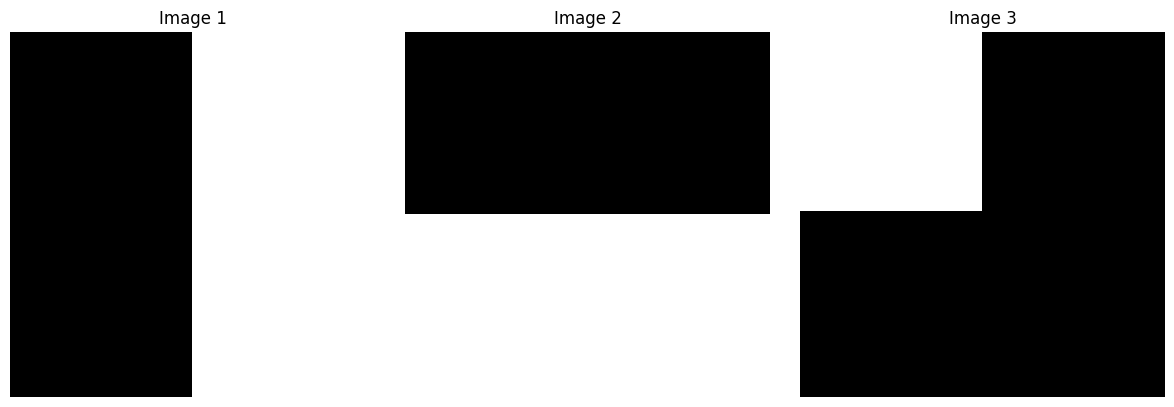

In [13]:
from PIL import Image
from numpy import asarray
import matplotlib.pyplot as plt

# Load images
image1 = Image.open('images/1.png')
image2 = Image.open('images/2.png')
image3 = Image.open('images/3.png')

# Convert images to NumPy arrays
data1 = asarray(image1)
data2 = asarray(image2)
data3 = asarray(image3)

# Plot using subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(data1)
axes[0].set_title("Image 1")
axes[0].axis('off')

axes[1].imshow(data2)
axes[1].set_title("Image 2")
axes[1].axis('off')

axes[2].imshow(data3)
axes[2].set_title("Image 3")
axes[2].axis('off')

plt.tight_layout()
plt.show()


*   Use the above three images to create the following image

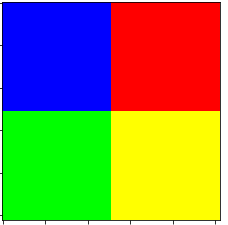
*Hint: Remember channels and color spaces*

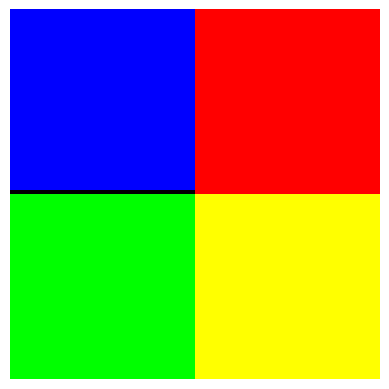

In [18]:
# solution
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load mask images
img1 = np.asarray(Image.open("images/1.png").convert("L"))  # Red mask
img2 = np.asarray(Image.open("images/2.png").convert("L"))  # Green mask
img3 = np.asarray(Image.open("images/3.png").convert("L"))  # Blue mask

R = img1
G = img2
B = img3

# Stack into RGB image
rgb = np.stack([R, G, B], axis=2).astype(np.uint8)

plt.imshow(rgb)
plt.axis("off")
plt.show()



### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

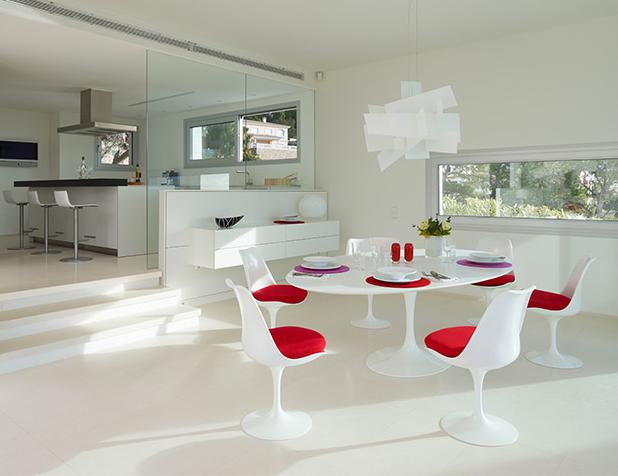

*   Extract individual channels and plot them using matplotlib subplot.



In [21]:
# solution
img = np.asarray(Image.open('images/sillas.jpg')).astype(np.uint8)


*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

(np.float64(-0.5), np.float64(617.5), np.float64(475.5), np.float64(-0.5))

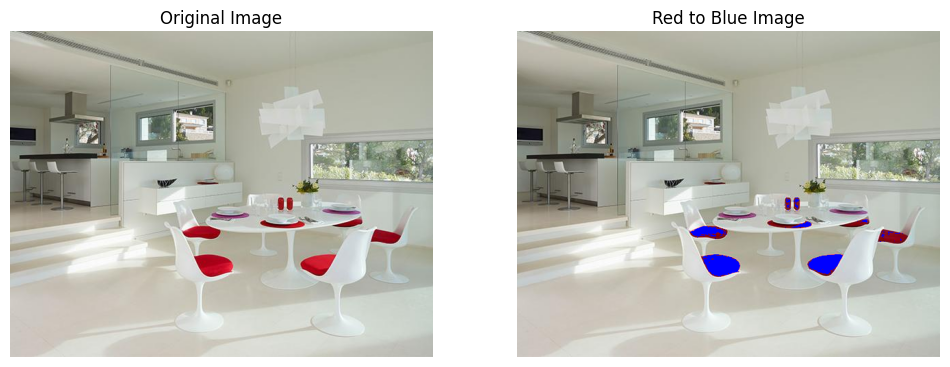

In [24]:
# solution


# Extract channels
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

red_mask = (R > 150) & (G < 100) & (B < 100)

result = img.copy()

result[red_mask] = [0, 0, 255]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Red to Blue Image")
plt.imshow(result)
plt.axis("off")



# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

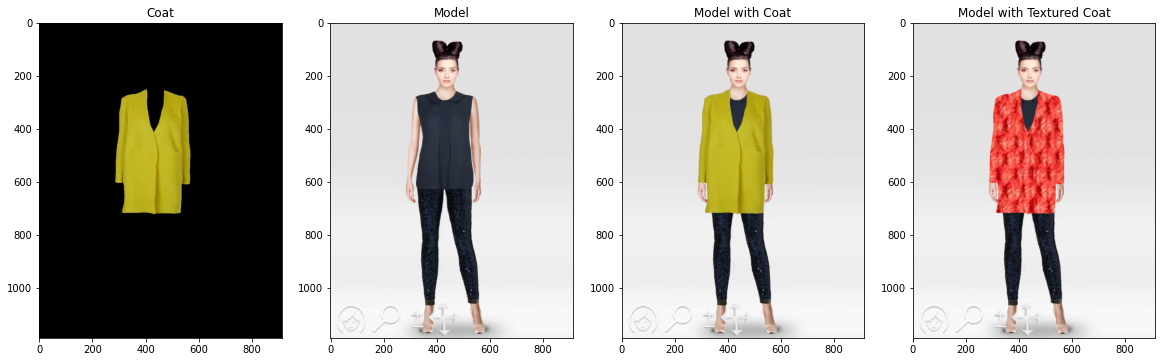

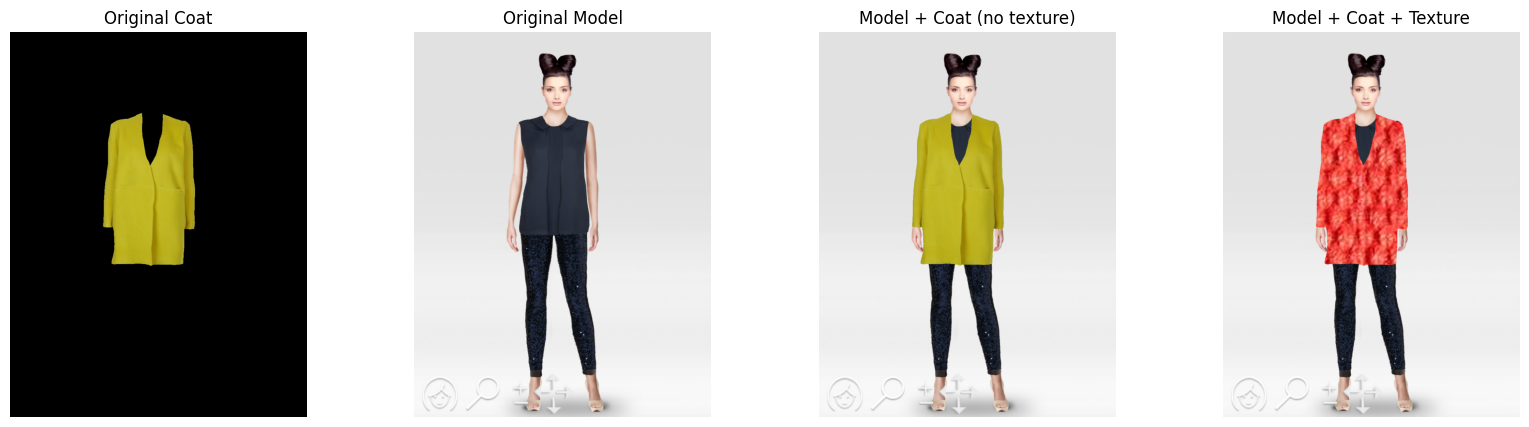

In [47]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load images
model = Image.open("images/model.png").convert("RGBA")
coat = Image.open("images/coat.png").convert("RGBA")
texture = Image.open("images/texture2.png").convert("RGBA")

# Convert coat to numpy array for mask creation
coat_np = np.array(coat)

# Create mask: keep non-black pixels of the coat
threshold = 50
mask = np.any(coat_np[:, :, :3] > threshold, axis=2).astype(np.uint8) * 255
mask_img = Image.fromarray(mask, mode="L")

# Coat over model (no texture)
coat_rgba = coat.copy()
coat_rgba.putalpha(mask_img)

coat_over_model = model.copy()
coat_over_model.paste(coat_rgba, (0, 0), coat_rgba)


# Coat with texture
# Ensure texture matches coat size
texture_resized = texture.resize(coat.size)
texture_resized.putalpha(mask_img)

# Coat with texture
coat_with_texture = Image.new("RGBA", coat.size)
coat_with_texture.paste(texture_resized, (0, 0), mask_img)


# Final overlay: coat with texture on model
final_output = model.copy()
final_output.paste(coat_with_texture, (0, 0), coat_with_texture)


# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(coat)
axes[0].set_title("Original Coat")
axes[0].axis("off")

axes[1].imshow(model)
axes[1].set_title("Original Model")
axes[1].axis("off")

axes[2].imshow(coat_over_model)
axes[2].set_title("Model + Coat (no texture)")
axes[2].axis("off")

axes[3].imshow(final_output)
axes[3].set_title("Model + Coat + Texture")
axes[3].axis("off")

plt.show()


# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




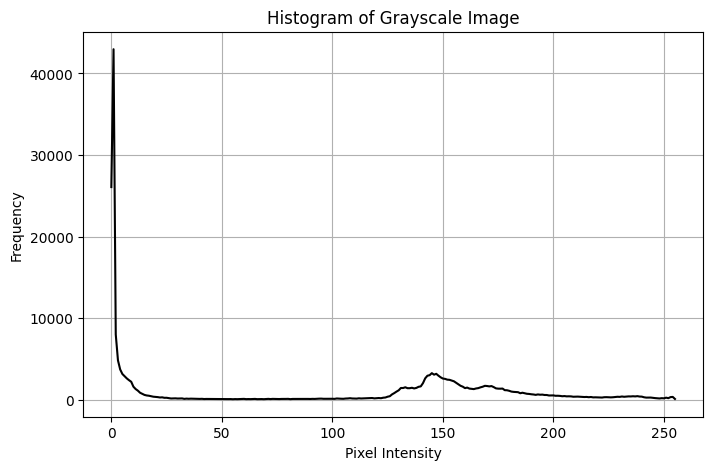

In [54]:
# solution
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, color
from skimage.io import imread

# Load image
astronaut = Image.open("images/astronaut.jpg").convert("RGBA")

# Convert to grayscale
astronaut_gray = astronaut.convert("L")  # "L" mode is grayscale

# Convert to numpy array
astronaut_np = np.array(astronaut_gray)

# Compute histogram using skimage.exposure
hist = exposure.histogram(astronaut_np)

# hist is a tuple: (hist_values, bin_centers)
hist_values, bin_centers = hist

# Plot histogram
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hist_values, color='black')
plt.title("Histogram of Grayscale Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()



*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

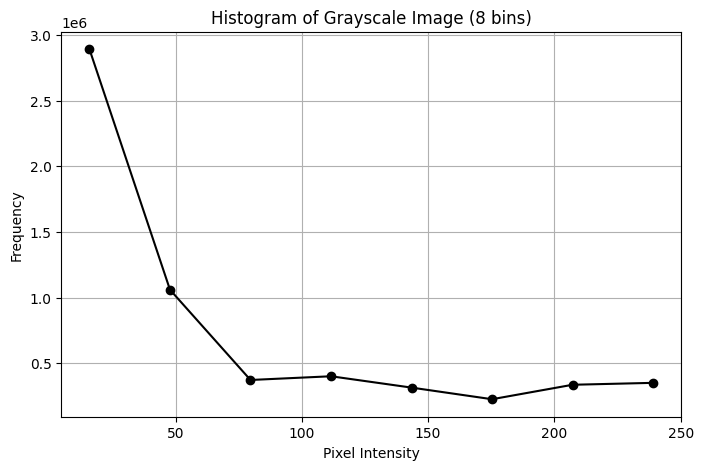

In [55]:
# solution
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
astronaut = Image.open("images/aquatermi_lowcontrast.jpg").convert("L")  # grayscale

# Convert to numpy array
astronaut_np = np.array(astronaut)

# Compute histogram with 8 bins
hist_values, bin_edges = np.histogram(astronaut_np, bins=8, range=(0, 255))

# Compute bin centers for plotting
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot histogram
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, hist_values, marker='o', linestyle='-', color='black')
plt.title("Histogram of Grayscale Image (8 bins)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()





*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



**Solution**

*(Double-click or enter to edit)*

changing the bin count to 8 reduced the granularity of the histogram

...


*   Compute histogram of the color image (without converting it to grayscale).
*   Plot the total histogram and also histogram for each channel (show it in a single plot with differnt legends for each histogram).


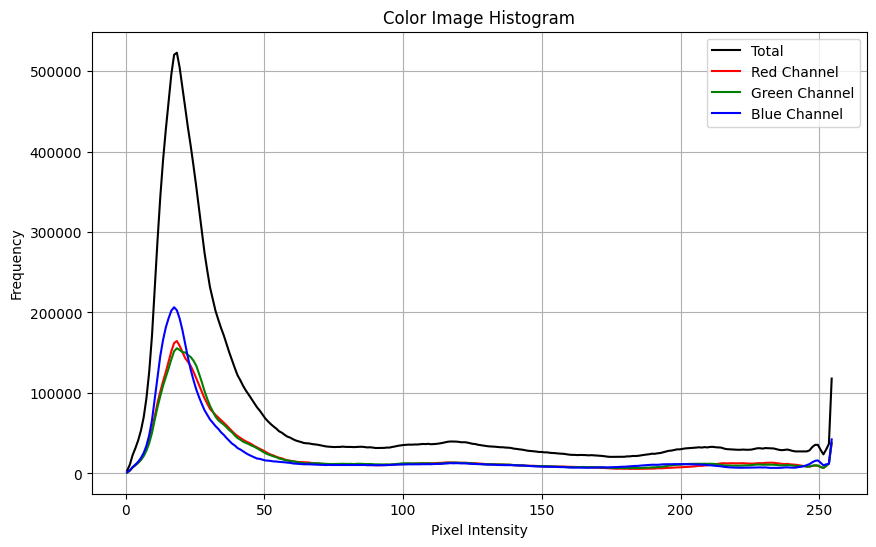

In [56]:
#solution

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load color image
astronaut = Image.open("images/aquatermi_lowcontrast.jpg").convert("RGB")

# Convert to numpy array
astronaut_np = np.array(astronaut)

# Separate channels
red_channel = astronaut_np[:, :, 0]
green_channel = astronaut_np[:, :, 1]
blue_channel = astronaut_np[:, :, 2]

# Compute histograms for each channel
hist_red, bins_red = np.histogram(red_channel, bins=256, range=(0, 255))
hist_green, bins_green = np.histogram(green_channel, bins=256, range=(0, 255))
hist_blue, bins_blue = np.histogram(blue_channel, bins=256, range=(0, 255))

# Total histogram (sum of all channels)
hist_total = hist_red + hist_green + hist_blue
bins_total = bins_red  # same bins for all channels

# Compute bin centers for plotting
bin_centers = (bins_total[:-1] + bins_total[1:]) / 2

# Plot histograms
plt.figure(figsize=(10, 6))
plt.plot(bin_centers, hist_total, color='black', label='Total')
plt.plot(bin_centers, hist_red, color='red', label='Red Channel')
plt.plot(bin_centers, hist_green, color='green', label='Green Channel')
plt.plot(bin_centers, hist_blue, color='blue', label='Blue Channel')
plt.title("Color Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


### **Exercise: Histogram Equalization**

*   Read 'aquatermi_lowcontrast.jpg' image from the images folder.
*   Compute the histogram of the image.
*   Perform histogram equalization of the image to enhance the contrast. *Hint: Use equalize_hist function available in skimage.exposure*
*   Also compute histogram of the equalized image.
*   Use 2 x 2 subplot to show the original image and the enhanced image along with the corresponding histograms.



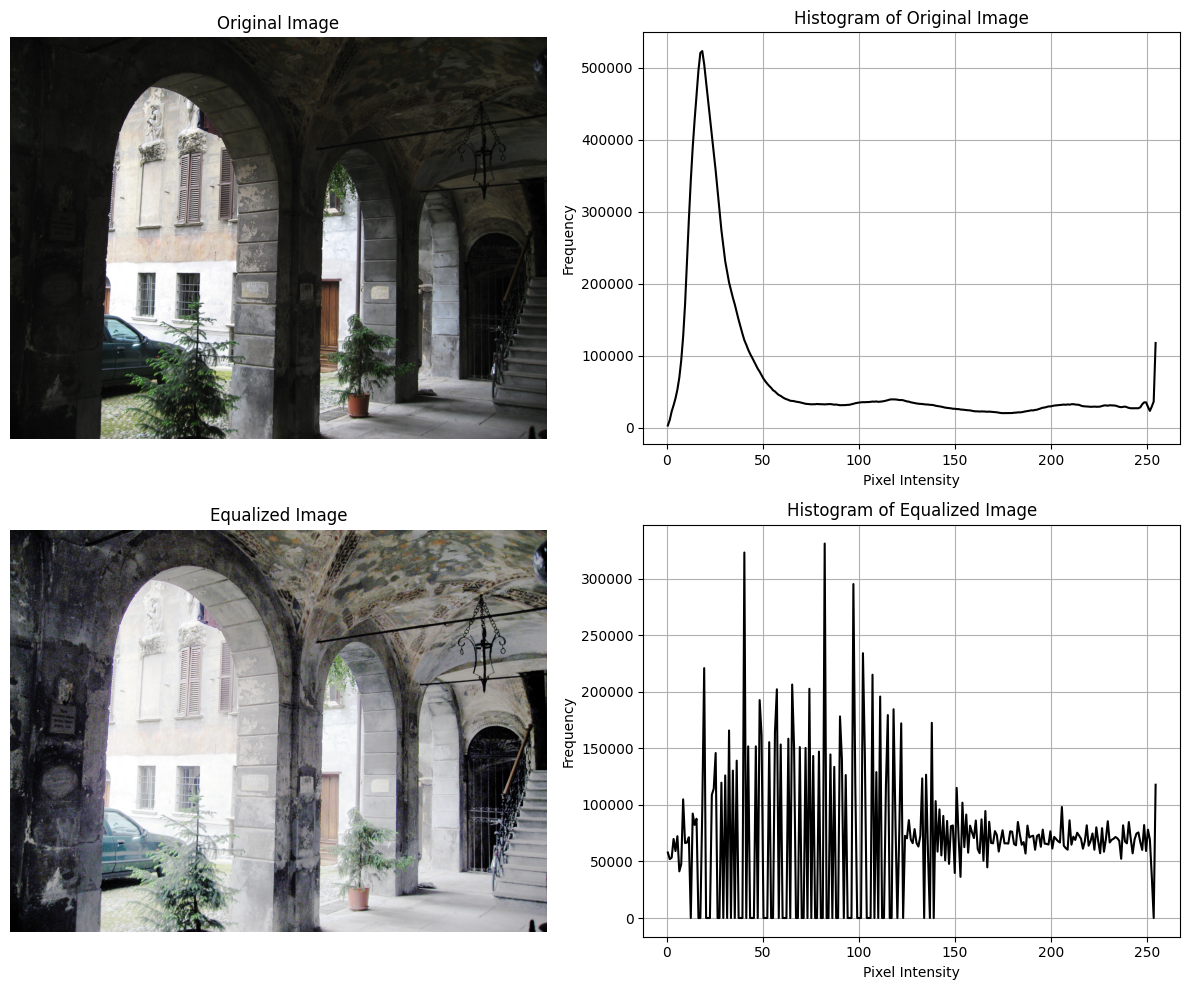

In [ ]:
# solution

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

# Load image
astronaut = Image.open("images/aquatermi_lowcontrast.jpg").convert("RGB")
astronaut_np = np.array(astronaut)


# Compute histogram of original image
# Flatten all channels to get total histogram
hist_orig, bins_orig = np.histogram(astronaut_np.flatten(), bins=256, range=(0, 255))
bin_centers_orig = (bins_orig[:-1] + bins_orig[1:]) / 2

# Histogram equalization
# Equalize histogram per channel
equalized_channels = []
for i in range(3):  # RGB channels
    eq_channel = exposure.equalize_hist(astronaut_np[:, :, i])
    # Convert to 0-255 and uint8
    eq_channel = (eq_channel * 255).astype(np.uint8)
    equalized_channels.append(eq_channel)

# Stack channels back
astronaut_eq_np = np.stack(equalized_channels, axis=2)

# Compute histogram of equalized image
hist_eq, bins_eq = np.histogram(astronaut_eq_np.flatten(), bins=256, range=(0, 255))
bin_centers_eq = (bins_eq[:-1] + bins_eq[1:]) / 2

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original image
axes[0, 0].imshow(astronaut_np)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Histogram of original image
axes[0, 1].plot(bin_centers_orig, hist_orig, color='black')
axes[0, 1].set_title("Histogram of Original Image")
axes[0, 1].set_xlabel("Pixel Intensity")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True)

# Equalized image
axes[1, 0].imshow(astronaut_eq_np)
axes[1, 0].set_title("Equalized Image")
axes[1, 0].axis("off")

# Histogram of equalized image
axes[1, 1].plot(bin_centers_eq, hist_eq, color='black')
axes[1, 1].set_title("Histogram of Equalized Image")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()




*   The above function in skimage.exposure uses cdf and interpolation technique to normalize the histogram. How is it different from linear contrast stretch?


**Solution**

*(Double-click or enter to edit)*

...

### **Exercise: Linear Contrast Stretch**

*   Write a function to compute the linear contrast stretch (Do not use an inbuilt function). 
*   Provide grayscale image array and bin count as parameters to the function and return the enhanced image array.
*   Use a 2 x 2 plot to visualize the original image, histogram, enhanced image and the corresponding histogram.



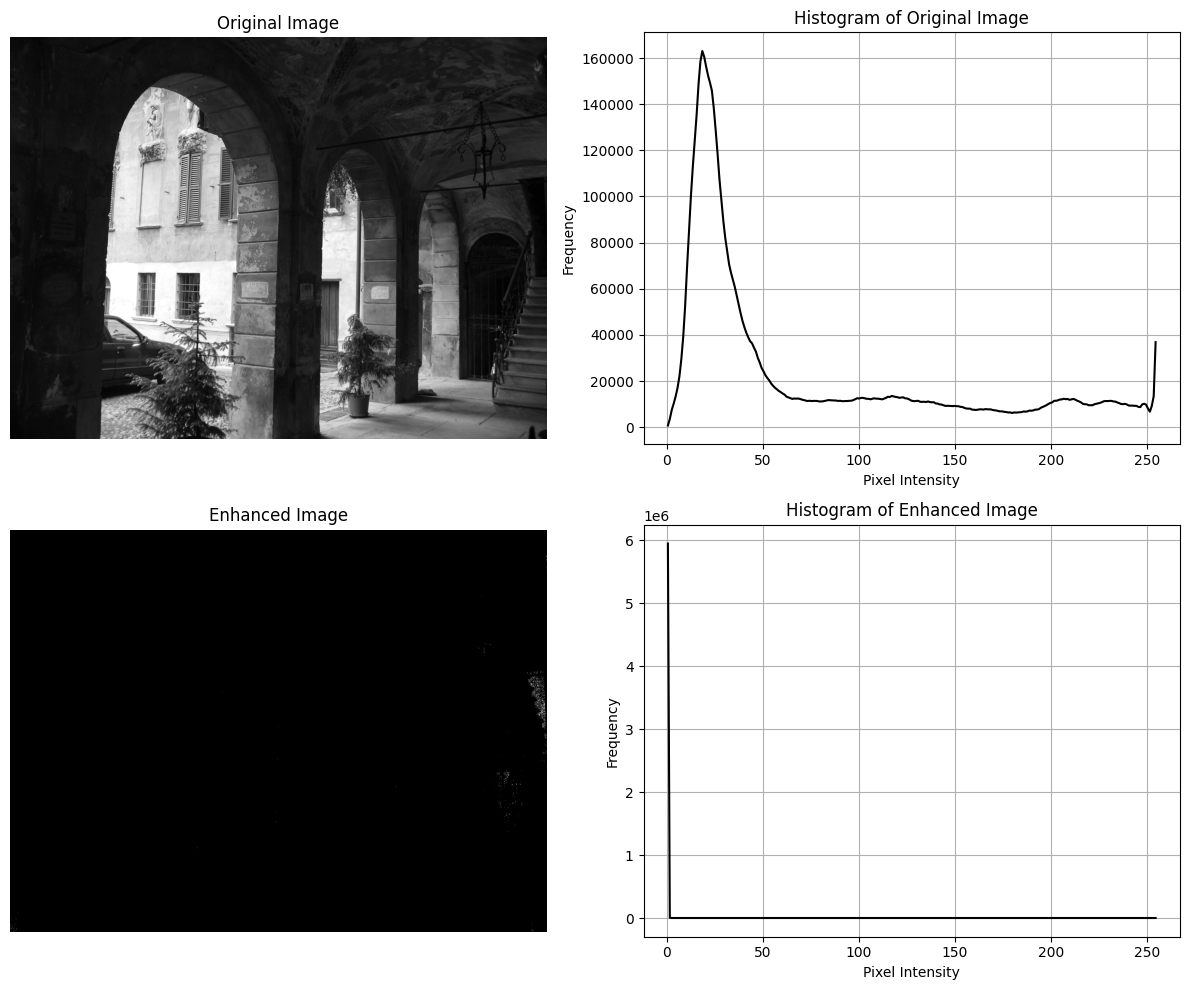

In [ ]:
# solution
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Linear contrast stretch function
def linear_contrast_stretch(gray_img, bins=256):   
    # Find minimum and maximum pixel values
    min_val = np.min(gray_img)
    max_val = np.max(gray_img)
    
    # Avoid division by zero
    if max_val == min_val:
        stretched_img = gray_img.copy()
    else:
        # Linear contrast stretch formula
        stretched_img = (gray_img - min_val) * 255 / (max_val - min_val)
        stretched_img = stretched_img.astype(np.uint8)
    
    return stretched_img


# Load image and convert to grayscale
img = Image.open("images/aquatermi_lowcontrast.jpg").convert("L")
img_np = np.array(img)


# Apply linear contrast stretch
enhanced_img_np = linear_contrast_stretch(img_np, bins=256)


# Compute histograms
hist_orig, bins_orig = np.histogram(img_np.flatten(), bins=256, range=(0, 255))
hist_enh, bins_enh = np.histogram(enhanced_img_np.flatten(), bins=256, range=(0, 255))
bin_centers_orig = (bins_orig[:-1] + bins_orig[1:]) / 2
bin_centers_enh = (bins_enh[:-1] + bins_enh[1:]) / 2


# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original grayscale image
axes[0, 0].imshow(img_np, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Histogram of original image
axes[0, 1].plot(bin_centers_orig, hist_orig, color='black')
axes[0, 1].set_title("Histogram of Original Image")
axes[0, 1].set_xlabel("Pixel Intensity")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].grid(True)

# Enhanced image
axes[1, 0].imshow(enhanced_img_np, cmap='gray')
axes[1, 0].set_title("Enhanced Image")
axes[1, 0].axis("off")

# Histogram of enhanced image
axes[1, 1].plot(bin_centers_enh, hist_enh, color='black')
axes[1, 1].set_title("Histogram of Enhanced Image")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()



# Filters

### **Exercise: Mean Filter**

*   Load the **coins** image from the data module.
*   Define a disk structuring element (selem) of radius 20. *Hint: Structuring elements are defined in the skimage.morphology module*
*   Use mean filter using the created selem. *Hint: The mean filter is available in skimage.filters.rank module*
*   Increase the radius of the selem by 10 and apply the mean filter.
*   Reduce the radius of the selem by 10 and apply the mean filter.
*   Visualize all the smoothened images along with the original image.




*   Use different selem (square, rectangle, star, diamond) to view the behaviour of the mean filter (It is not necessary to repeat with different sizes; it is sufficient to show the one with optimal parameter).
*   Create a 2 x n subplot to show the selem in the first row and the corresponding smoothened image in the second row.

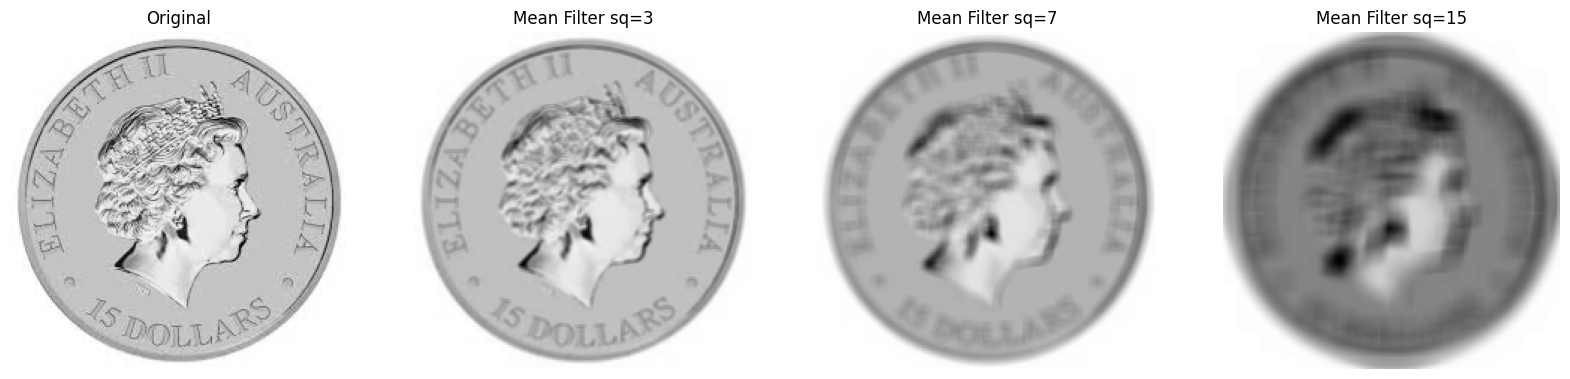

In [72]:
from skimage.morphology import square
from skimage.filters import rank
from PIL import Image
import numpy as np
from skimage import img_as_ubyte
import matplotlib.pyplot as plt

# Load image and convert to grayscale
coin = Image.open("images/coins.jpeg").convert("L")
coin = np.array(coin)
coin = img_as_ubyte(coin)

# Create square structuring elements with different sizes
selem_3 = square(3)
selem_7 = square(7)
selem_15 = square(15)

# Apply mean filter with each square selem
mean_3 = rank.mean(coin, selem_3)
mean_7 = rank.mean(coin, selem_7)
mean_15 = rank.mean(coin, selem_15)

# Plot original and filtered images
plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(coin, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Mean Filter sq=3")
plt.imshow(mean_3, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Mean Filter sq=7")
plt.imshow(mean_7, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Mean Filter sq=15")
plt.imshow(mean_15, cmap='gray')
plt.axis('off')

plt.show()


*   How does changing the radius of disk affect the smoothing functionality?

**Solution**

The radius of the disk structuring element determines the size of the neighborhood over which the mean filter averages pixel values:

Small radius: Only nearby pixels are included -> less smoothing. Fine details and edges are mostly preserved.

Large radius: More pixels are included in the averaging -> stronger smoothing. Edges and fine details start to blur.

...

*   What is the observed behaviour with difference in the structuring element?

**Solution**

Disk (disk(radius))
Radially symmetric (circular).
Smoothing is uniform in all directions
Preserves curved edges and natural shapes better.
Less likely to introduce directional artifacts.

Square (square(size))
Axis-aligned (rows and columns).
Smoothing is strong along horizontal/vertical directions, weaker along diagonals.
Can create slightly blocky artifacts for large squares.
Curved edges may appear more “stepped” after filtering.


...



*   What is the difference between mean filter and gaussian filter?
*   Where do you use mean filters and where do you use gaussian filters?



**Solution**

A mean filter smooths an image by averaging all pixels in a neighborhood equally, which can blur edges noticeably. A Gaussian filter also smooths the image but gives more weight to pixels near the center, producing a more natural blur that preserves edges better.

...